# **Phase 5 - Advanced Product Analytics & Customer Segmentation**

In [3]:
import pandas as pd

master = pd.read_csv("master_dataset.csv")

In [4]:
master.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,delivery_days,approval_hours,delivery_delay_days,order_month,order_year
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149.0,...,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,8.0,0.178333,-8.0,2017-10,2017.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149.0,...,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,8.0,0.178333,-8.0,2017-10,2017.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149.0,...,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,8.0,0.178333,-8.0,2017-10,2017.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813.0,...,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,13.0,30.713889,-6.0,2018-07,2018.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265.0,...,5.0,NaN,NaN,2018-08-18,2018-08-22 19:07:58,9.0,0.276111,-18.0,2018-08,2018.0


In [5]:
master["order_purchase_timestamp"] = pd.to_datetime(master["order_purchase_timestamp"])
master["order_delivered_customer_date"] = pd.to_datetime(master["order_delivered_customer_date"])
master["order_estimated_delivery_date"] = pd.to_datetime(master["order_estimated_delivery_date"])

# **Step 1 - Customer Lifetime Value (CLV)**
**Business Question**

Which customers generate the highest revenue?

In [6]:
customer_clv = (
    master.groupby("customer_unique_id")["payment_value"]
          .sum()
          .sort_values(ascending=False)
)

customer_clv.head(10)

,payment_value
customer_unique_id,
0a0a92112bd4c708ca5fde585afaa872,109312.64
eae0a83d752b1dd32697e0e7b4221656,21874.05
1b76903617af13189607a36b0469f6f3,19174.38
d97b3cfb22b0d6b25ac9ed4e9c2d481b,18786.90
9eca552063680b7cd2ed0e8aea002b21,17786.88
244024d753ef305e66b7ef97f3813ebd,11697.12
931eabdf0636b8fd60369a8d759917d6,10999.26
a229eba70ec1c2abef51f04987deb7a5,8891.00
c5365631fcd0f5ae1802e798e1b7d692,7667.84


NameError: name 'plt' is not defined

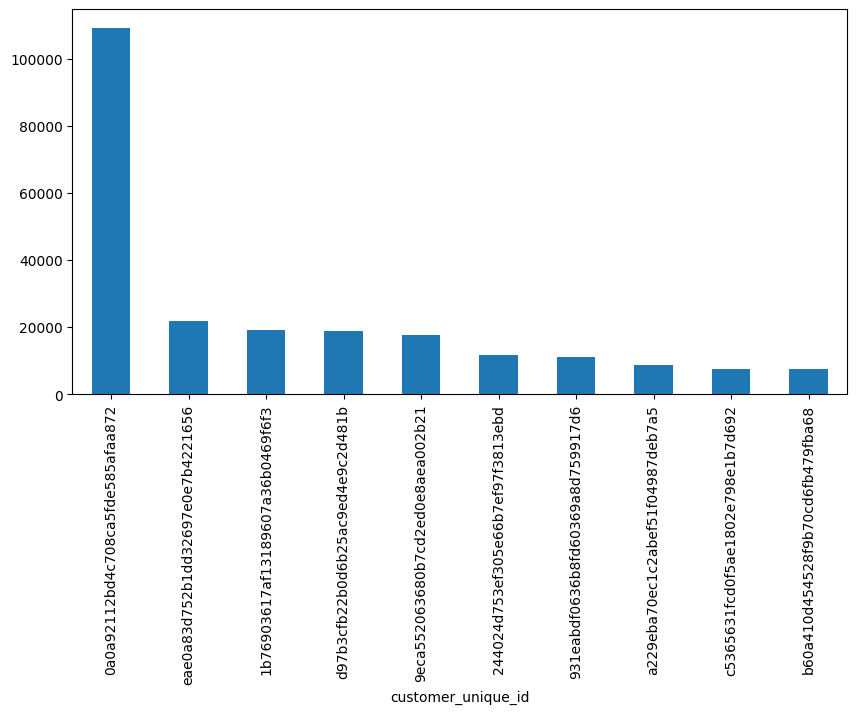

In [7]:
customer_clv.head(10).plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Customers by Customer Lifetime Value")
plt.xlabel("Customer")
plt.ylabel("Revenue")

plt.show()

# **Step 2 - Purchase Frequency**
**Business Question**

How many orders has each customer placed?

In [8]:
purchase_frequency = (
    master.groupby("customer_unique_id")["order_id"]
          .nunique()
          .sort_values(ascending=False)
)

purchase_frequency.head(10)

,order_id
customer_unique_id,
8d50f5eadf50201ccdcedfb9e2ac8455,5
738ffcf1017b584e9d2684b36e07469c,3
a1874c5550d2f0bc14cc122164603713,3
862bcdd9344546914b93a16397a78791,2
e424731f7e9ccc9f3384b8b71378cbf7,2
a5c806ebe5b25d0ab1e7f0da0e17d6bc,2
b8d31a82b1bb71983bbc08e4751baeab,2
c5400d2fca348bd1313426efe4b10a51,2
d970a2354b55cfb67fa5840b9b4936ed,2


# **Step 3 - Repeat Customer Rate**

In [9]:
repeat_customers = purchase_frequency[purchase_frequency > 1].count()

total_customers = purchase_frequency.count()

repeat_rate = (repeat_customers / total_customers) * 100

print(f"Repeat Customer Rate: {repeat_rate:.2f}%")

Repeat Customer Rate: 0.73%


# **Step 4 - Product Category Performance**
Revenue by Category

In [10]:
category_summary = (
    master.groupby("product_category_name_english")
    .agg({
        "payment_value":"sum",
        "review_score":"mean",
        "order_id":"count"
    })
)

category_summary = category_summary.rename(columns={
    "payment_value":"Revenue",
    "review_score":"Average Rating",
    "order_id":"Orders"
})

category_summary.sort_values(
    "Revenue",
    ascending=False
).head(10)

,Revenue,Average Rating,Orders
product_category_name_english,,,
bed_bath_table,341124.15,3.868950,2212
health_beauty,338348.41,4.176038,1915
watches_gifts,307537.02,4.018062,1228
computers_accessories,298520.03,3.956354,1564
sports_leisure,262185.43,4.104298,1753
furniture_decor,253627.23,3.964966,1642
housewares,201928.13,4.072298,1402
auto,171371.44,4.047673,884
cool_stuff,159101.05,4.142132,796


# **Step 5 - High Revenue but Low Ratings**

In [11]:
high_revenue_low_rating = category_summary[
    (category_summary["Revenue"] > category_summary["Revenue"].median()) &
    (category_summary["Average Rating"] < 4)
]

high_revenue_low_rating

,Revenue,Average Rating,Orders
product_category_name_english,,,
bed_bath_table,341124.15,3.868950,2212
computers,62791.98,3.755556,46
computers_accessories,298520.03,3.956354,1564
construction_tools_construction,53586.91,3.668571,176
fixed_telephony,123863.47,2.964912,57
furniture_decor,253627.23,3.964966,1642
garden_tools,151558.75,3.986699,830
home_confort,18871.54,3.900000,111
home_construction,32335.73,3.758333,120


# **Step 6 - Customer Satisfaction by State**

In [12]:
state_rating = (
    master.groupby("customer_state")["review_score"]
          .mean()
          .sort_values(ascending=False)
)

state_rating

,review_score
customer_state,
AP,4.222222
MT,4.187135
ES,4.183771
SP,4.136011
TO,4.134615
MS,4.125000
MG,4.075905
PB,4.045802
PR,4.042002


# **Step 7 - Revenue by State**

In [13]:
state_revenue = (
    master.groupby("customer_state")["payment_value"]
          .sum()
          .sort_values(ascending=False)
)

state_revenue

,payment_value
customer_state,
SP,1483479.99
RJ,628125.92
MG,422498.00
RS,216904.52
PR,215062.29
SC,164354.79
BA,163297.45
GO,92666.04
PE,77628.94


# **Step 8 - Delivery Performance vs Ratings**
**Business Question**

Do delivery delays affect customer satisfaction?

In [14]:
delivery_rating = (
    master.groupby("delivery_delay_days")["review_score"]
          .mean()
)

delivery_rating.head()

,review_score
delivery_delay_days,
-140.0,5.0
-69.0,1.0
-68.0,5.0
-64.0,5.0
-62.0,5.0


# **Step 9 - Monthly Orders**

NameError: name 'plt' is not defined

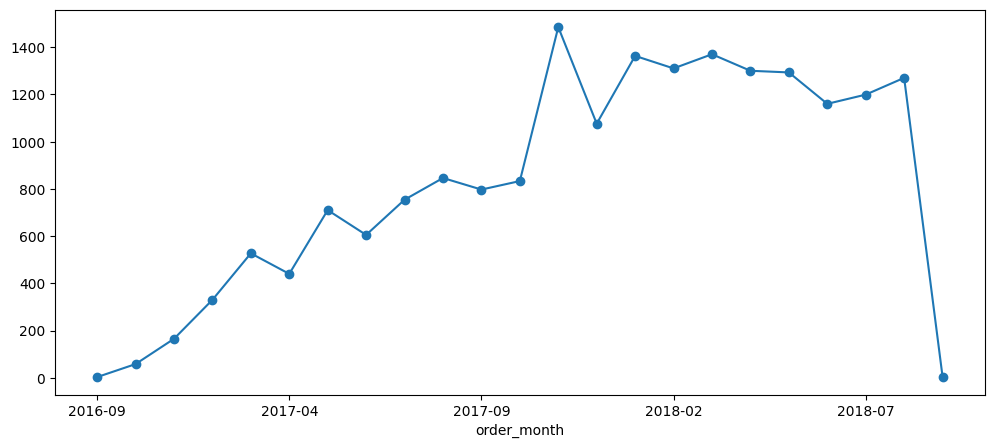

In [15]:
monthly_orders = (
    master.groupby("order_month")["order_id"]
          .nunique()
)

monthly_orders.plot(figsize=(12,5), marker='o')

plt.title("Monthly Orders")

plt.show()

# **Step 10 - Executive KPI Table**

In [16]:
executive_kpi = pd.DataFrame({

    "Metric":[
        "Total Revenue",
        "Total Customers",
        "Repeat Customer Rate",
        "Average Rating",
        "Average Delivery Time"
    ],

    "Value":[
        round(master["payment_value"].sum(),2),
        master["customer_unique_id"].nunique(),
        round(repeat_rate,2),
        round(master["review_score"].mean(),2),
        round(master["delivery_days"].mean(),2)
    ]
})

executive_kpi

,Metric,Value
0,Total Revenue,3993553.61
1,Total Customers,18758.00
2,Repeat Customer Rate,0.73
3,Average Rating,4.03
4,Average Delivery Time,12.04
